# Post Read 3: Advanced Topics in Statistics

Welcome to **Post Read 3**, where we delve into advanced and specialized topics that extend beyond the main lecture series. This material is designed for self-study, providing you with deeper insights, rigorous proofs, and exploration of niche areas in statistics. Whether you're looking to solidify your understanding of foundational theorems or explore cutting-edge methodologies, this post has you covered.

---

## Introduction

In this **Post Read**, we explore **advanced proofs**, **deeper Bayesian methodologies**, and **rare statistical distributions**. These topics are essential for those looking to push the boundaries of their statistical knowledge and apply sophisticated techniques to complex problems.

- **Advanced Proofs**: Rigorous derivations that underpin fundamental theorems.
- **Hierarchical Bayesian Methods**: Extending Bayesian inference to multi-level models.
- **Rare Distributions**: Understanding and applying specialized statistical distributions.
- **Mini Case Studies**: Practical applications of advanced methods on synthetic data.

💡 **Key Insight**: Mastery of these advanced topics equips you with the tools to tackle complex real-world data challenges.

---

## Advanced Proof of the Central Limit Theorem

The **Central Limit Theorem (CLT)** is a cornerstone of statistics, stating that the distribution of the sample mean approaches a normal distribution as the sample size grows, regardless of the original distribution of the data.

### Formal Statement

<font color="skyblue">**Central Limit Theorem**</font>:  
*Let $ X_1, X_2, \dots, X_n $ be independent and identically distributed random variables with mean $ \mu $ and variance $ \sigma^2 $. Then, as $ n \to \infty $, the distribution of the standardized sample mean approaches a standard normal distribution:*

$
\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \xrightarrow{d} \mathcal{N}(0, 1)
$

### Proof Outline Using Characteristic Functions

To prove the CLT, we utilize **characteristic functions**, which uniquely define the distribution of a random variable.

1. **Characteristic Function of the Sample Mean**:
   
   For $ \bar{X}_n = \frac{1}{n} \sum_{i=1}^n X_i $, the characteristic function is:

   $
   \phi_{\bar{X}_n}(t) = \left( \phi_X\left(\frac{t}{n}\right) \right)^n
   $

2. **Standardization**:
   
   Standardize $ \bar{X}_n $:

   $
   \phi_{Z_n}(t) = \phi_{\bar{X}_n}\left(\frac{t\sigma}{\sqrt{n}}\right) = \left( \phi_X\left(\frac{t\sigma}{n^{3/2}}\right) \right)^n
   $

3. **Taylor Expansion**:
   
   Expand $ \phi_X(t) $ around $ t = 0 $:

   $
   \phi_X(t) = 1 + i\mu t - \frac{\sigma^2 t^2}{2} + o(t^2)
   $

4. **Limit as $ n \to \infty $**:
   
   Substituting the expansion into the characteristic function of $ Z_n $:

   $
   \phi_{Z_n}(t) \approx \left(1 - \frac{\sigma^2 t^2}{2n} + o\left(\frac{1}{n}\right)\right)^n \xrightarrow{n \to \infty} e^{-\sigma^2 t^2 / 2}
   $

5. **Conclusion**:
   
   The limiting characteristic function corresponds to the standard normal distribution, hence:

   $
   Z_n \xrightarrow{d} \mathcal{N}(0, 1)
   $

💡 **Insight**: The use of characteristic functions elegantly handles the convergence of distributions by leveraging their unique properties.

### Empirical Verification of CLT

Let's empirically verify the CLT by simulating the sampling distribution of the mean from a non-normal distribution.



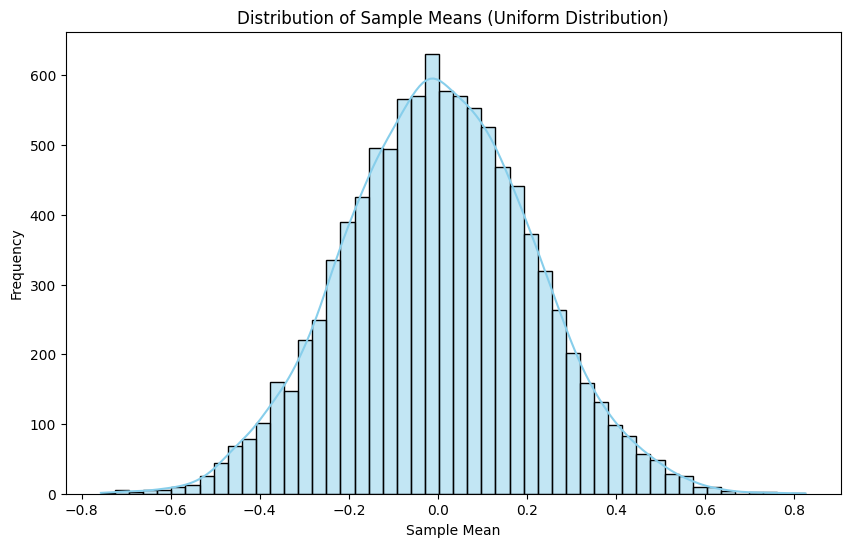

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_samples = 10000
sample_size = 30

# Generate samples from a uniform distribution
samples = np.random.uniform(low=-2, high=2, size=(n_samples, sample_size))
sample_means = samples.mean(axis=1)

# Plot the distribution of sample means
plt.figure(figsize=(10,6))
sns.histplot(sample_means, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Sample Means (Uniform Distribution)')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.show()

---

## Hierarchical Bayesian Inference

**Hierarchical Bayesian models** extend standard Bayesian frameworks by introducing multiple levels of parameters, allowing for more flexible and realistic modeling of complex data structures.

### Overview

- **Hierarchy Levels**: Parameters are structured in layers, where higher-level parameters govern the distributions of lower-level ones.
- **Benefits**: Incorporates partial pooling, improves estimates for groups with limited data, and models complex dependencies.

<font color="green">**Hierarchical Bayesian Model Structure**</font>:

1. **Data Level**:
   
   $
   y_{ij} \sim \mathcal{N}(\theta_j, \sigma^2)
   $

   Where:
   - $ y_{ij} $ is the $ i $-th observation in group $ j $.
   - $ \theta_j $ is the mean of group $ j $.
   - $ \sigma^2 $ is the variance.

2. **Group Level**:
   
   $
   \theta_j \sim \mathcal{N}(\mu, \tau^2)
   $

   Where:
   - $ \mu $ is the overall mean.
   - $ \tau^2 $ is the variance between groups.

3. **Hyperpriors**:
   
   $
   \mu \sim \mathcal{N}(0, 10^2)
   $
   
   $
   \tau^2 \sim \text{Inverse-Gamma}(a, b)
   $

### Derivation of the Posterior Distribution

To derive the posterior, we apply Bayes' theorem considering all hierarchy levels.

$
P(\mu, \tau^2, \theta | y) \propto P(y | \theta, \sigma^2) \cdot P(\theta | \mu, \tau^2) \cdot P(\mu) \cdot P(\tau^2)
$

Where:
- $ P(y | \theta, \sigma^2) $ is the likelihood.
- $ P(\theta | \mu, \tau^2) $ is the group-level prior.
- $ P(\mu) $ and $ P(\tau^2) $ are the hyperpriors.

💡 **Key Insight**: Hierarchical models allow borrowing strength across groups, leading to more robust parameter estimates, especially in cases with sparse data.



---

## Exploring the Beta-Binomial Distribution

The **Beta-Binomial distribution** is a discrete probability distribution that arises from a binomial distribution with a Beta-distributed probability parameter. It is useful for modeling overdispersed binomial data.

### Definition

If $ p \sim \text{Beta}(\alpha, \beta) $ and given $ p $, $ X \sim \text{Binomial}(n, p) $, then the marginal distribution of $ X $ is **Beta-Binomial**:

$
P(X = k) = \binom{n}{k} \frac{B(k + \alpha, n - k + \beta)}{B(\alpha, \beta)}
$

Where $ B(\cdot, \cdot) $ is the Beta function.

### Properties

- **Mean**:
  
  $
  \mathbb{E}[X] = n \cdot \frac{\alpha}{\alpha + \beta}
  $

- **Variance**:
  
  $
  \text{Var}(X) = n \cdot \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)} \cdot (\alpha + \beta + n)
  $

### Applications

- **Modeling Overdispersion**: Captures extra variability not explained by the standard binomial model.
- **Bayesian Inference**: Serves as a conjugate prior in hierarchical models.

### Example

Consider modeling the number of successes in $ n = 10 $ trials with $ \alpha = 2 $ and $ \beta = 5 $.

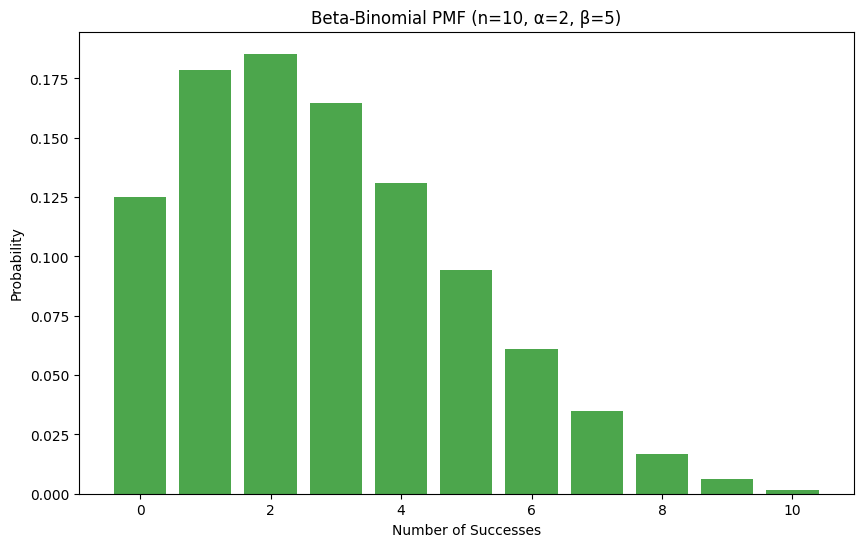

In [ ]:
from scipy.stats import betabinom
import matplotlib.pyplot as plt
import numpy as np

# Parameters
n = 10
alpha = 2
beta = 5

# Range of successes
k = np.arange(0, n+1)

# PMF of Beta-Binomial
pmf = betabinom.pmf(k, n, alpha, beta)

# Plot
plt.figure(figsize=(10,6))
plt.bar(k, pmf, color='green', alpha=0.7)
plt.title('Beta-Binomial PMF (n=10, α=2, β=5)')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.show()

💡 **Insight**: The Beta-Binomial distribution provides a flexible framework for modeling count data with inherent variability beyond the assumptions of the binomial distribution.

---

## Practice & Exploration

To solidify your understanding of the advanced topics covered, engage with the following exercises:

1. **Central Limit Theorem Proof**:
   
   - **Exercise**: Extend the CLT proof using the method of moments instead of characteristic functions.
   - **Challenge**: Explore the Lindeberg-Feller theorem and its implications for the CLT.

2. **Beta-Binomial Distribution**:
   
   - **Exercise**: Derive the moment generating function of the Beta-Binomial distribution.
   - **Challenge**: Compare the Beta-Binomial to the Negative Binomial distribution in modeling overdispersed count data.

3. **Numerical Experiments**:
   
   - **Exercise**: Simulate data from a Beta-Binomial distribution and estimate its parameters using maximum likelihood.
   - **Challenge**: Apply Bayesian inference to estimate Beta-Binomial parameters with informative priors.

💡 **Tip**: Tackling these exercises will deepen your comprehension and enhance your ability to apply advanced statistical techniques in diverse scenarios.

---